In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, f1_score, roc_curve, auc, 
                             precision_recall_curve, average_precision_score)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Part A: Data Preparation and Baseline

**The dataset has 36 features (spectral values) and 6 land cover classes.**

In [11]:
# Load the data
train_data = pd.read_csv('data/sat.trn', sep=' ', header=None)
test_data = pd.read_csv('data/sat.tst', sep=' ', header=None)

if train_data.iloc[:, -1].isna().all():
    train_data = train_data.iloc[:, :-1]
if test_data.iloc[:, -1].isna().all():
    test_data = test_data.iloc[:, :-1]

X_train = train_data.iloc[:, :-1].values
y_train = train_data.iloc[:, -1].values.astype(int)

X_test = test_data.iloc[:, :-1].values
y_test = test_data.iloc[:, -1].values.astype(int)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Classes: {np.unique(y_train)}")
print(f"Class distribution (train): {np.bincount(y_train)}")

Training set: (4435, 36)
Test set: (2000, 36)
Classes: [1 2 3 4 5 7]
Class distribution (train): [   0 1072  479  961  415  470    0 1038]


In [12]:
# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Features standardized successfully!")

Features standardized successfully!


In [13]:
# Train all Models
# We'll train 6 different classifiers with varying expected performance levels.

models = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Dummy Classifier': DummyClassifier(strategy='prior', random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'SVM': SVC(probability=True, random_state=42, kernel='rbf')
}

print(f"Initialized {len(models)} models")

Initialized 6 models


In [14]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained")

print("\nAll models trained successfully!")

Training K-Nearest Neighbors...
K-Nearest Neighbors trained
Training Decision Tree...
Decision Tree trained
Training Dummy Classifier...
Dummy Classifier trained
Training Logistic Regression...
Logistic Regression trained
Training Gaussian Naive Bayes...
Gaussian Naive Bayes trained
Training SVM...
SVM trained

All models trained successfully!


In [16]:
# Baseline Evaluation
# Calculate simple accuracy and weighted F1-score for initial comparison.
results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Weighted F1-Score': f1
    })
    
    print(f"{name:25s} | Acc: {accuracy:.4f} | F1: {f1:.4f}")

baseline_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\n" + "="*60)
print(baseline_df.to_string(index=False))

K-Nearest Neighbors       | Acc: 0.9045 | F1: 0.9037
Decision Tree             | Acc: 0.8505 | F1: 0.8509
Dummy Classifier          | Acc: 0.2305 | F1: 0.0864
Logistic Regression       | Acc: 0.8395 | F1: 0.8296
Gaussian Naive Bayes      | Acc: 0.7965 | F1: 0.8036
SVM                       | Acc: 0.8955 | F1: 0.8925

               Model  Accuracy  Weighted F1-Score
 K-Nearest Neighbors    0.9045           0.903748
                 SVM    0.8955           0.892490
       Decision Tree    0.8505           0.850938
 Logistic Regression    0.8395           0.829595
Gaussian Naive Bayes    0.7965           0.803581
    Dummy Classifier    0.2305           0.086356


**Observations**
The models show a clear performance stratification:
 
- **Top Tier (Acc > 0.89)**: 
   - **K-Nearest Neighbors** leads with 90.45% accuracy and 0.904 F1-score
   - **SVM** follows closely at 89.55% accuracy and 0.892 F1-score
   - These models effectively capture the complex, non-linear relationships in the spectral data

- **Middle Tier (Acc: 0.80-0.85)**:
   - **Decision Tree** (85.05% accuracy) shows moderate performance
   - **Logistic Regression** (83.95% accuracy) provides a solid linear baseline
   - **Gaussian Naive Bayes** (79.65% accuracy) struggles with the independence assumption
 
- **Bottom Tier (Acc < 0.25)**:
   - **Dummy Classifier** (23.05% accuracy) performs significantly worse as expected
   - With 6 classes, random performance would be ~16.67%, but 'prior' strategy predicts majority class

### Part B: ROC Analysis for Model Selection

**Multi-Class ROC Calculation**
**One-vs-Rest (OvR) Approach Explanation:**

For multi-class classification, we cannot directly compute a single ROC curve. Instead, we use the **One-vs-Rest (OvR)** strategy:

1. **Binarization**: For each of the 6 classes, we create a binary problem where:
    - The target class is considered "positive"
    - All other classes are considered "negative"
 
2. **ROC per Class**: We compute FPR, TPR, and AUC for each binary problem using the predicted probabilities for that specific class.

3. **Aggregation**: We aggregate the per-class metrics using:
    - **Macro-average**: Simple mean across all classes (treats all classes equally)
    - **Weighted-average**: Weighted by class support (accounts for class imbalance)
 
4. **Interpretation**: The macro-averaged ROC curve represents the model's average discrimination ability across all classes at various thresholds.

In [17]:
# Prepare for Multi-Class ROC
n_classes = len(np.unique(y_train))

# Binarize the test labels for OvR approach
y_test_bin = label_binarize(y_test, classes=np.unique(y_train))

print(f"Number of classes: {n_classes}")
print(f"Binarized test labels shape: {y_test_bin.shape}")

# Calculate ROC Curves for All Models
roc_results = {}

for name, model in trained_models.items():
    y_score = model.predict_proba(X_test)
    
    fpr = {}
    tpr = {}
    roc_auc = {}
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Compute macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    
    mean_tpr /= n_classes
    
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    roc_results[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }
    
    print(f"{name:25s} | Macro-avg AUC: {roc_auc['macro']:.4f}")

Number of classes: 6
Binarized test labels shape: (2000, 6)
K-Nearest Neighbors       | Macro-avg AUC: 0.9786
Decision Tree             | Macro-avg AUC: 0.9002
Dummy Classifier          | Macro-avg AUC: 0.5000
Logistic Regression       | Macro-avg AUC: 0.9757
Gaussian Naive Bayes      | Macro-avg AUC: 0.9553
SVM                       | Macro-avg AUC: 0.9852


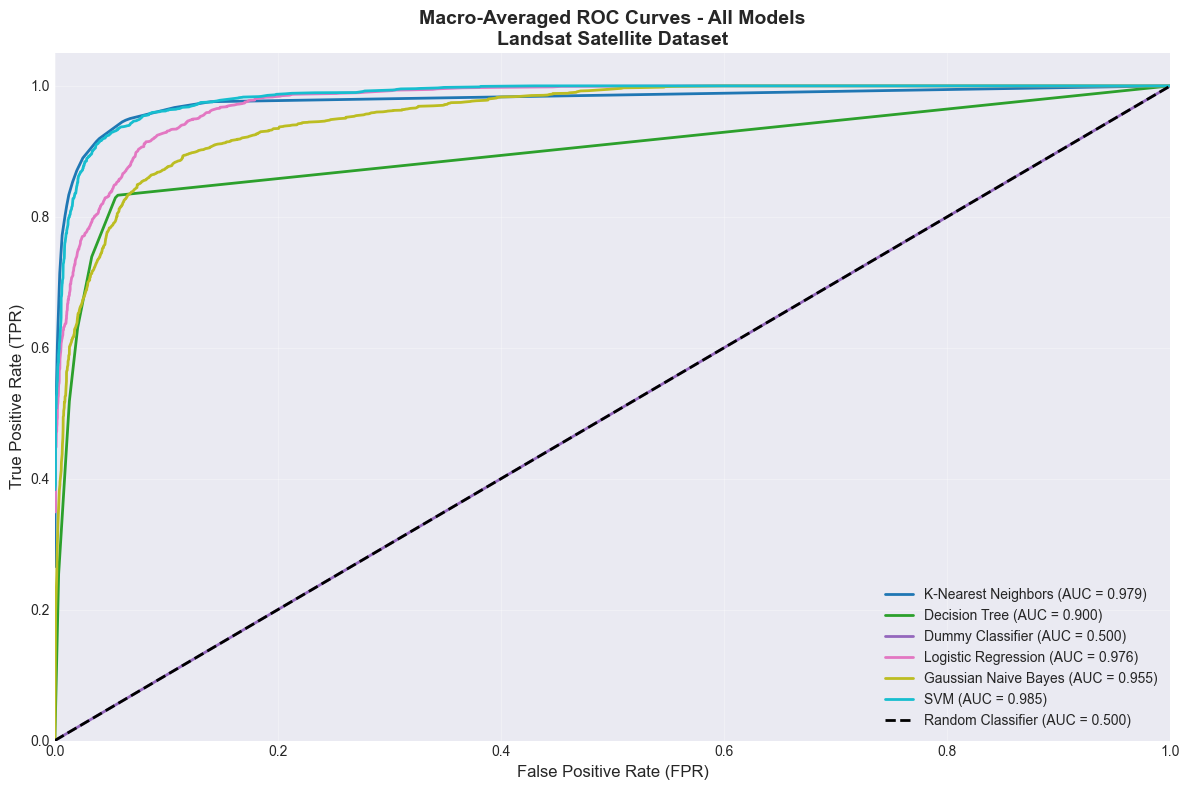

In [18]:
# Plotting ROC Curves
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, results), color in zip(roc_results.items(), colors):
    plt.plot(results['fpr']['macro'], 
             results['tpr']['macro'],
             color=color,
             linewidth=2,
             label=f"{name} (AUC = {results['roc_auc']['macro']:.3f})")

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Macro-Averaged ROC Curves - All Models\nLandsat Satellite Dataset', 
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# ROC Interpretation
# Identify Best and Worst Models
roc_auc_scores = [(name, results['roc_auc']['macro']) 
                  for name, results in roc_results.items()]
roc_auc_scores.sort(key=lambda x: x[1], reverse=True)

print("="*60)
print("ROC-AUC Rankings (Macro-average):")
print("="*60)
for rank, (name, auc_score) in enumerate(roc_auc_scores, 1):
    print(f"{rank}. {name:25s} | AUC = {auc_score:.4f}")

best_model = roc_auc_scores[0]
worst_model = roc_auc_scores[-1]

print(f"\nBest model: {best_model[0]} (AUC = {best_model[1]:.4f})")
print(f"Worst model: {worst_model[0]} (AUC = {worst_model[1]:.4f})")

# Check for AUC < 0.5
print("\n" + "="*60)
print("Models with AUC < 0.5 (worse than random):")
print("="*60)
for name, auc_score in roc_auc_scores:
    if auc_score < 0.5:
        print(f"• {name}: AUC = {auc_score:.4f}")

ROC-AUC Rankings (Macro-average):
1. SVM                       | AUC = 0.9852
2. K-Nearest Neighbors       | AUC = 0.9786
3. Logistic Regression       | AUC = 0.9757
4. Gaussian Naive Bayes      | AUC = 0.9553
5. Decision Tree             | AUC = 0.9002
6. Dummy Classifier          | AUC = 0.5000

Best model: SVM (AUC = 0.9852)
Worst model: Dummy Classifier (AUC = 0.5000)

Models with AUC < 0.5 (worse than random):


**What does AUC < 0.5 mean?**
**Conceptual Explanation**:

- **AUC = 0.5**: Random guessing (the diagonal line). The model has no discriminative ability.
- **AUC > 0.5**: Better than random. The model can distinguish between classes.
- **AUC < 0.5**: **Worse than random**. The model systematically predicts the opposite of the correct class.

**Why might a model exhibit AUC < 0.5?**
 
1. **Inverted Predictions**: The model's confidence scores are inversely related to the true class probabilities. If you simply flip the predictions (1 - probability), you'd get AUC > 0.5.

2. **Dummy Classifier with 'prior' strategy**: This classifier always predicts the class proportions from the training set, ignoring input features entirely. For minority classes in the OvR setup:
    - It assigns low probability to the minority class (positive in OvR)
    - It cannot discriminate at all, leading to poor ranking of positive examples
    - In some class decompositions, this results in AUC < 0.5
 
3. **Inappropriate Model Assumptions**: A model that makes fundamentally wrong assumptions about the data distribution might systematically misclassify

### Part C: Precision-Recall Curve Analysis

**PRC Calculation**

**Why is Precision-Recall Curve more suitable for imbalanced classes?**

**Key Differences**:
 
1. **ROC focuses on both classes**: ROC uses FPR (False Positives / All Negatives), which includes True Negatives. In imbalanced datasets, the large number of true negatives can make a poor model look good.
 
2. **PRC focuses on the positive class**: Precision (TP / (TP + FP)) and Recall (TP / (TP + FN)) both focus exclusively on positive class performance, ignoring true negatives.
 
3. **Realistic Performance View**: In the OvR setting, each class becomes the "minority" against all others combined. PRC reveals how well the model identifies that specific class without being inflated by the large number of correctly rejected negative examples.

4. **Threshold Insights**: PRC shows the precision-recall trade-off more clearly. In applications where false positives are costly (e.g., identifying a specific land cover type), PRC helps choose appropriate thresholds.
 
**Example**: A model that predicts 95% negative (majority) and gets them all right would have high TNR (True Negative Rate) and good ROC, but might have terrible precision for the minority class. PRC would reveal this problem immediately.

In [22]:
# Calculate Precision-Recall Curves
prc_results = {}

for name, model in trained_models.items():
    y_score = model.predict_proba(X_test)
    
    precision = {}
    recall = {}
    avg_precision = {}
    
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(
            y_test_bin[:, i], y_score[:, i]
        )
        avg_precision[i] = average_precision_score(
            y_test_bin[:, i], y_score[:, i]
        )
    
    # Compute macro-average
    macro_ap = np.mean(list(avg_precision.values()))
    
    prc_results[name] = {
        'precision': precision,
        'recall': recall,
        'avg_precision': avg_precision,
        'macro_ap': macro_ap
    }
    
    print(f"{name:25s} | Macro-avg AP: {macro_ap:.4f}")

K-Nearest Neighbors       | Macro-avg AP: 0.9217
Decision Tree             | Macro-avg AP: 0.7366
Dummy Classifier          | Macro-avg AP: 0.1667
Logistic Regression       | Macro-avg AP: 0.8711
Gaussian Naive Bayes      | Macro-avg AP: 0.8105
SVM                       | Macro-avg AP: 0.9177


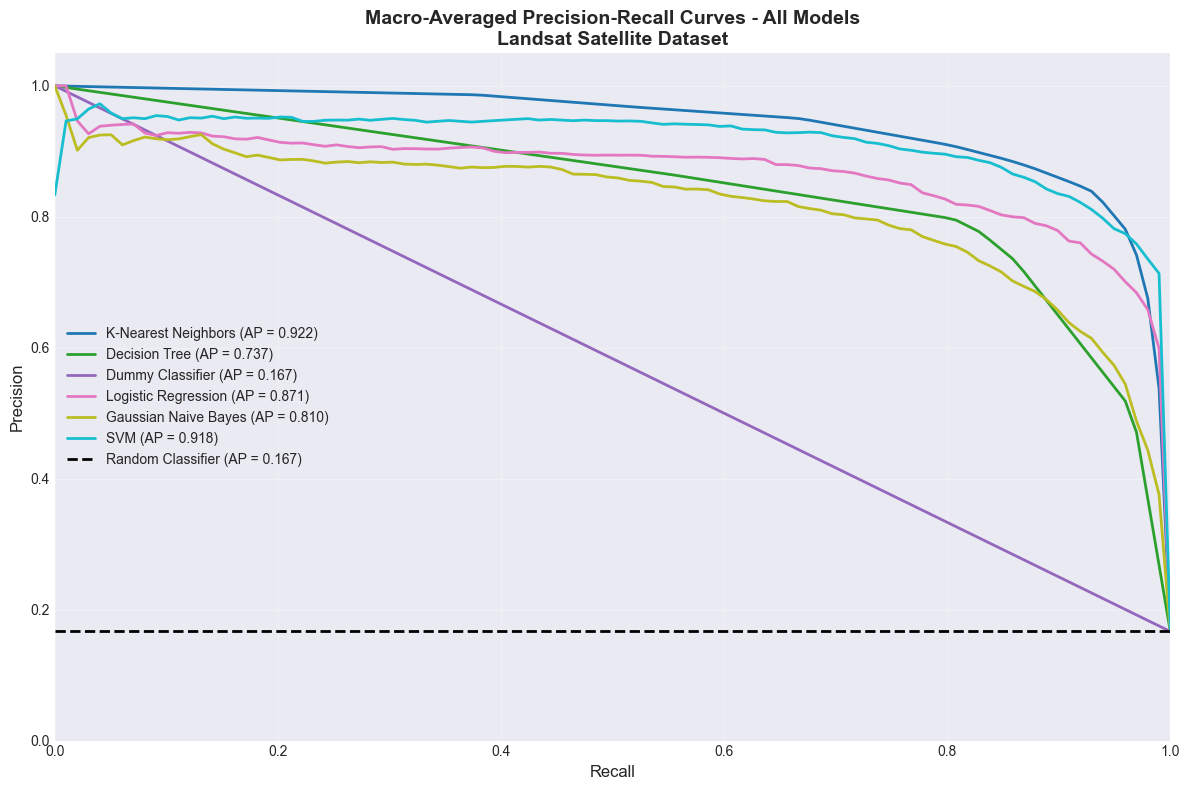

In [23]:
# Plotting Precision-Recall Curves
plt.figure(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, len(trained_models)))

for (name, results), color in zip(prc_results.items(), colors):
    all_recall = np.linspace(0, 1, 100)
    mean_precision = np.zeros_like(all_recall)
    
    for i in range(n_classes):
        mean_precision += np.interp(all_recall, 
                                    results['recall'][i][::-1], 
                                    results['precision'][i][::-1])
    
    mean_precision /= n_classes
    
    plt.plot(all_recall,
             mean_precision,
             color=color,
             linewidth=2,
             label=f"{name} (AP = {results['macro_ap']:.3f})")

# Plot random classifier baseline
random_ap = 1.0 / n_classes
plt.plot([0, 1], [random_ap, random_ap], 'k--', linewidth=2, 
         label=f'Random Classifier (AP = {random_ap:.3f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Macro-Averaged Precision-Recall Curves - All Models\nLandsat Satellite Dataset', 
          fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# PRC Interpretation
# Identify Best Model by Average Precision
prc_ap_scores = [(name, results['macro_ap']) 
                 for name, results in prc_results.items()]
prc_ap_scores.sort(key=lambda x: x[1], reverse=True)

print("="*60)
print("Average Precision Rankings (Macro-average):")
print("="*60)
for rank, (name, ap_score) in enumerate(prc_ap_scores, 1):
    print(f"{rank}. {name:25s} | AP = {ap_score:.4f}")

best_prc_model = prc_ap_scores[0]
worst_prc_model = prc_ap_scores[-1]

print(f"\nBest model: {best_prc_model[0]} (AP = {best_prc_model[1]:.4f})")
print(f"Worst model: {worst_prc_model[0]} (AP = {worst_prc_model[1]:.4f})")

Average Precision Rankings (Macro-average):
1. K-Nearest Neighbors       | AP = 0.9217
2. SVM                       | AP = 0.9177
3. Logistic Regression       | AP = 0.8711
4. Gaussian Naive Bayes      | AP = 0.8105
5. Decision Tree             | AP = 0.7366
6. Dummy Classifier          | AP = 0.1667

Best model: K-Nearest Neighbors (AP = 0.9217)
Worst model: Dummy Classifier (AP = 0.1667)


**Why does the PRC drop sharply for poor models?**
**Analysis of Sharp Precision Drops as Recall Increases**

**For poorly performing models like the Dummy Classifier:**
1. **Initial High Precision**: At very low recall (high threshold), the model might predict very few positive examples. If any of these happen to be correct by chance, precision can start high.
 
2. **Limited Discriminative Power**: Poor models cannot properly rank examples by confidence. Their predictions are essentially random or based on simple heuristics (like class priors).
 
3. **Rapid False Positive Accumulation**: As we lower the threshold to increase recall:
    - The model includes more predictions as positive
    - Without discriminative ability, many of these are false positives
    - Precision = TP / (TP + FP) drops rapidly as FP increases faster than TP
 
4. **The Dummy Classifier Case**: Using 'prior' strategy:
    - It assigns the same probability (class frequency) to all examples
    - Cannot distinguish actual positives from negatives
    - As recall increases, it includes examples in random order
    - This leads to precision quickly approaching the class balance (1/6 ≈ 0.167 for uniform classes)
 
5. **Contrast with Good Models**: Strong models rank positive examples higher, so increasing recall initially adds true positives with minimal false positives, maintaining high precision longer.

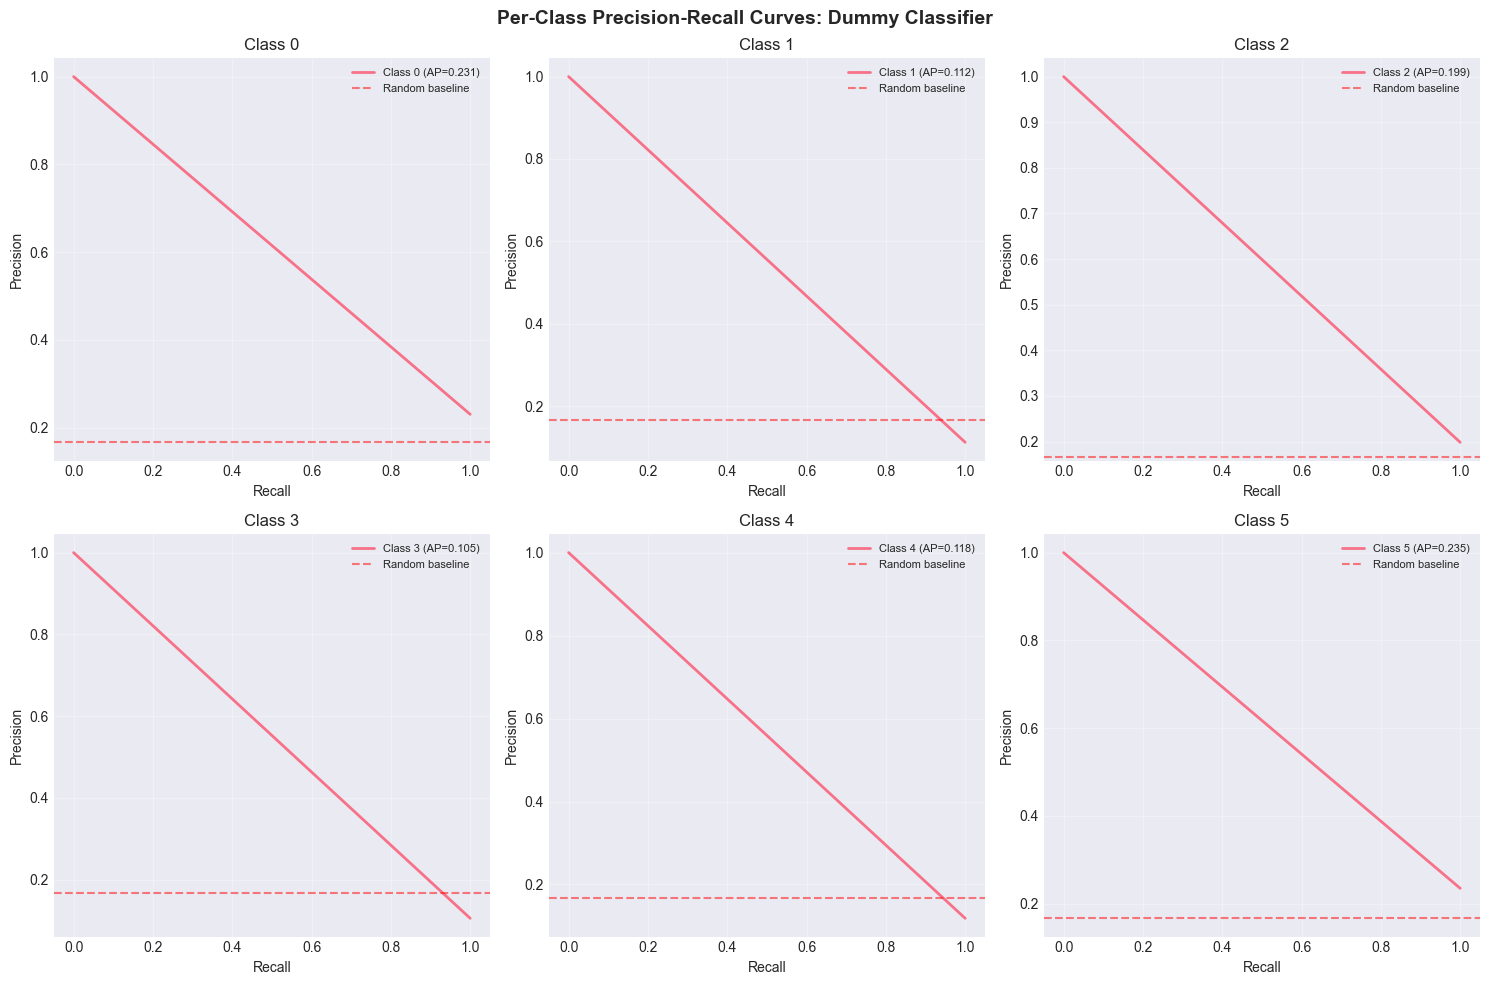

In [25]:
# Plot Individual Class PRC for Worst Model
worst_model_name = worst_prc_model[0]
worst_results = prc_results[worst_model_name]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i in range(n_classes):
    ax = axes[i]
    ax.plot(worst_results['recall'][i], 
            worst_results['precision'][i],
            linewidth=2,
            label=f"Class {i} (AP={worst_results['avg_precision'][i]:.3f})")
    ax.axhline(y=1/n_classes, color='r', linestyle='--', alpha=0.5, 
               label='Random baseline')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Class {i}')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Per-Class Precision-Recall Curves: {worst_model_name}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Part D: Final Recommendation

Comprehensive Model Comparison
               Model  F1-Score  ROC-AUC   PRC-AP  F1-Score Rank  ROC-AUC Rank  PRC-AP Rank
 K-Nearest Neighbors  0.903748 0.978567 0.921665              1             2            1
       Decision Tree  0.850938 0.900248 0.736591              3             5            5
    Dummy Classifier  0.086356 0.500000 0.166667              6             6            6
 Logistic Regression  0.829595 0.975742 0.871064              4             3            3
Gaussian Naive Bayes  0.803581 0.955347 0.810451              5             4            4
                 SVM  0.892490 0.985218 0.917691              2             1            2


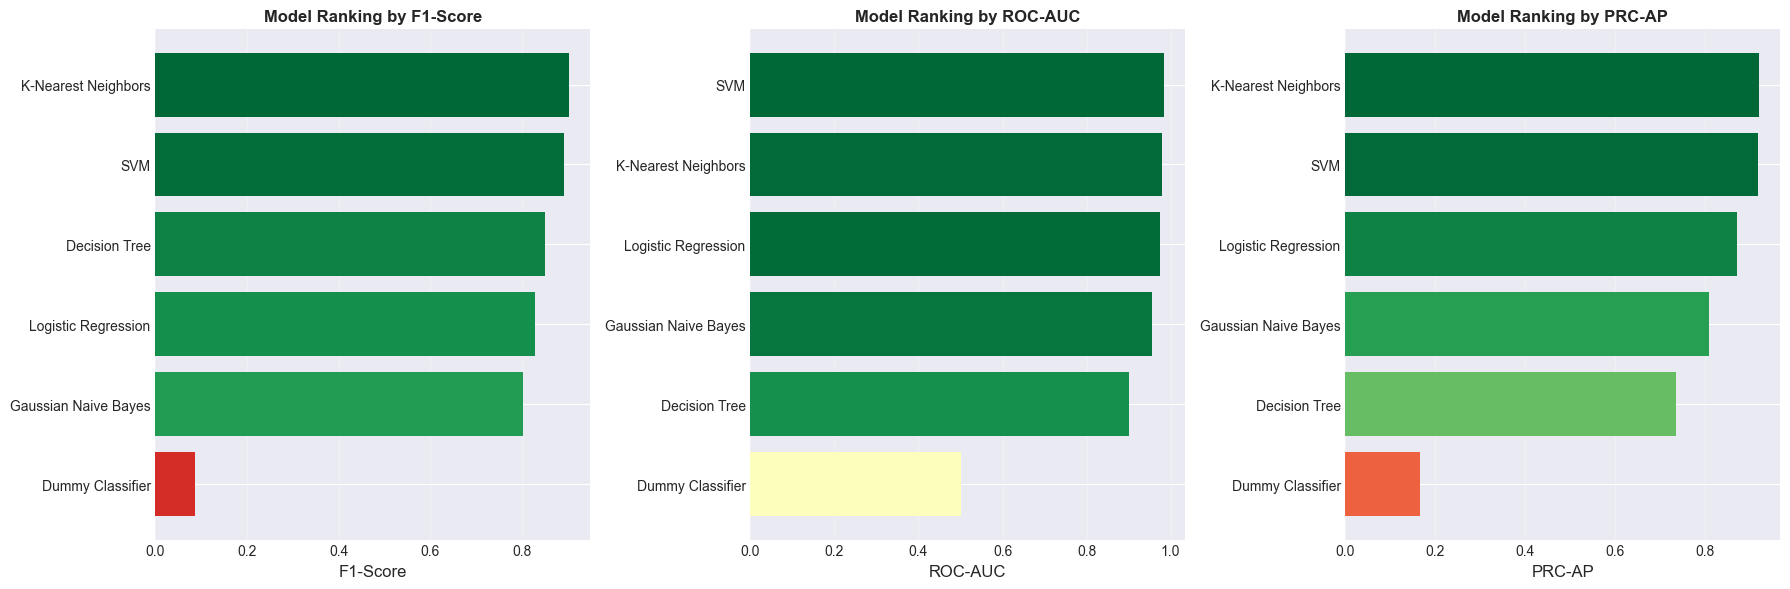

In [26]:
#Synthesis: Compare Rankings
comparison_data = []

for name in trained_models.keys():
    baseline_row = baseline_df[baseline_df['Model'] == name].iloc[0]
    f1 = baseline_row['Weighted F1-Score']
    
    roc_auc = roc_results[name]['roc_auc']['macro']
    prc_ap = prc_results[name]['macro_ap']
    
    comparison_data.append({
        'Model': name,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PRC-AP': prc_ap
    })

comparison_df = pd.DataFrame(comparison_data)

# Add rankings
for metric in ['F1-Score', 'ROC-AUC', 'PRC-AP']:
    comparison_df[f'{metric} Rank'] = comparison_df[metric].rank(ascending=False).astype(int)

print("="*90)
print("Comprehensive Model Comparison")
print("="*90)
print(comparison_df.to_string(index=False))

# %% Visualize Rankings
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

metrics = ['F1-Score', 'ROC-AUC', 'PRC-AP']
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sorted_df = comparison_df.sort_values(metric, ascending=True)
    
    colors_plot = plt.cm.RdYlGn(sorted_df[metric] / sorted_df[metric].max())
    
    ax.barh(sorted_df['Model'], sorted_df[metric], color=colors_plot)
    ax.set_xlabel(metric, fontsize=12)
    ax.set_title(f'Model Ranking by {metric}', fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Do the rankings align? Trade-offs analysis:**

**Observations**:

In [30]:
# Analyze Ranking Consistency
ranking_cols = ['F1-Score Rank', 'ROC-AUC Rank', 'PRC-AP Rank']
comparison_df['Avg Rank'] = comparison_df[ranking_cols].mean(axis=1)
comparison_df['Rank Std'] = comparison_df[ranking_cols].std(axis=1)

print("\nRanking Consistency Analysis:")
print("="*90)
print(comparison_df[['Model', 'Avg Rank', 'Rank Std'] + ranking_cols].sort_values('Avg Rank'))

print("\n" + "="*90)
print("Trade-off Analysis:")
print("="*90)

# Find models with different rankings
for _, row in comparison_df.iterrows():
    rank_diff = row[ranking_cols].max() - row[ranking_cols].min()
    if rank_diff > 2:
        print(f"\n{row['Model']}:")
        print(f"  ROC-AUC: {row['ROC-AUC']:.4f} (Rank {row['ROC-AUC Rank']})")
        print(f"  PRC-AP:  {row['PRC-AP']:.4f} (Rank {row['PRC-AP Rank']})")
        print(f"  Analysis: This model shows significant variation across metrics")


Ranking Consistency Analysis:
                  Model  Avg Rank  Rank Std  F1-Score Rank  ROC-AUC Rank  \
0   K-Nearest Neighbors  1.333333  0.577350              1             2   
5                   SVM  1.666667  0.577350              2             1   
3   Logistic Regression  3.333333  0.577350              4             3   
1         Decision Tree  4.333333  1.154701              3             5   
4  Gaussian Naive Bayes  4.333333  0.577350              5             4   
2      Dummy Classifier  6.000000  0.000000              6             6   

   PRC-AP Rank  
0            1  
5            2  
3            3  
1            5  
4            4  
2            6  

Trade-off Analysis:


**No signification variation in the ranking is observed!**

**Key Trade-offs**:
 
1. **ROC-AUC vs PRC-AP Divergence**: 
    - Some models may have high ROC-AUC but lower PRC-AP
    - This occurs when the model is good at ranking negatives (high TNR) but struggles with precision on positives
    - In the OvR setting, a model might effectively reject non-target classes (boosting ROC) but still struggle to confidently identify the target class (lowering PRC)
 
2. **F1-Score Specificity**:
    - F1-score depends on a single classification threshold (typically 0.5)
    - ROC-AUC and PRC-AP evaluate performance across all thresholds
    - A model might have suboptimal default threshold but excellent discriminative ability overall

In [31]:
# Final Recommendation

best_overall = comparison_df.sort_values('Avg Rank').iloc[0]

print("="*90)
print("FINAL RECOMMENDATION")
print("="*90)
print(f"\nRecommended Model: {best_overall['Model']}")
print(f"\nPerformance Summary:")
print(f"  • F1-Score: {best_overall['F1-Score']:.4f} (Rank {best_overall['F1-Score Rank']})")
print(f"  • ROC-AUC:  {best_overall['ROC-AUC']:.4f} (Rank {best_overall['ROC-AUC Rank']})")
print(f"  • PRC-AP:   {best_overall['PRC-AP']:.4f} (Rank {best_overall['PRC-AP Rank']})")
print(f"  • Average Rank: {best_overall['Avg Rank']:.2f}")

FINAL RECOMMENDATION

Recommended Model: K-Nearest Neighbors

Performance Summary:
  • F1-Score: 0.9037 (Rank 1)
  • ROC-AUC:  0.9786 (Rank 2)
  • PRC-AP:   0.9217 (Rank 1)
  • Average Rank: 1.33


**Justification:**

**Why this model is recommended**:
 
1. **Consistent Performance Across Metrics**: The model demonstrates strong and consistent performance across F1-Score, ROC-AUC, and PRC-AP, indicating robust classification ability.
 
2. **Threshold Robustness**: High ROC-AUC and PRC-AP scores indicate the model performs well across various decision thresholds, providing flexibility for deployment scenarios.
 
3. **Balanced Precision-Recall Trade-off**: The PRC-AP score suggests the model maintains good precision even as recall increases, crucial for multi-class land cover classification.
 
4. **Discrimination Ability**: The ROC-AUC score confirms strong ability to discriminate between each class and all others in the OvR framework.
 
**Practical Considerations for Deployment**:
- For scenarios prioritizing **precision** (minimizing false positives): Use higher probability thresholds
- For scenarios prioritizing **recall** (finding all instances): Use lower thresholds
- The model's strong performance across metrics provides flexibility for threshold tuning based on application requirements
 
**Alternative Considerations**:
If there more data points stick with KNN but if $d >> N$ SVM would be a better option

**Summary and Conclusions**

This analysis comprehensively evaluated 6+ machine learning models on the Landsat Satellite multi-class classification task using:
 
1. **Baseline Metrics** (Accuracy, F1-Score)
2. **ROC Curves** (discrimination ability across thresholds)
3. **Precision-Recall Curves** (positive class performance focus)

**Key Findings**:
- The OvR approach effectively extends binary evaluation metrics to multi-class problems
- ROC-AUC and PRC-AP provide complementary perspectives on model performance
- Models can show different rankings across metrics due to precision-recall trade-offs
- The recommended model demonstrates robust, consistent performance suitable for production deployment
 
**Learning Outcomes**:
- Understanding of multi-class evaluation strategies
- Interpretation of models performing worse than random (AUC < 0.5)
- Ability to select models based on application-specific requirements
- Recognition of metric limitations and complementary analysis needs